In [73]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
import joblib

In [75]:
df= pd.read_csv(r'C:\Users\obian\OneDrive\Documents\SJ Lytix Projects\Investor Persona\cleaned_data.csv')

In [77]:
df.head(2)

,gender,age,Investment_Avenues,Mutual_Funds,Equity_Market,Debentures,Government_Bonds,Fixed_Deposits,PPF,Gold,...,Avenue,What are your savings objectives?,Reason_Equity,Reason_Mutual,Reason_Bonds,Reason_FD,Source,Risky_Score,Safe_Score,Investor_Profile
0,Female,34,Yes,1,2,5,3,7,6,4,...,Mutual Fund,Retirement Plan,Capital Appreciation,Better Returns,Safe Investment,Fixed Returns,Newspapers and Magazines,3,10,Aggressive
1,Female,23,Yes,4,3,2,1,5,6,7,...,Mutual Fund,Health Care,Dividend,Better Returns,Safe Investment,High Interest Rates,Financial Consultants,7,6,Aggressive


In [79]:
mod_df = df.copy()

In [81]:
df['Investor_Profile'] = df['Investor_Profile'].replace({
    'Conservative': 'Safe',
    'Moderate': 'Safe',
    'Aggressive': 'Risk'
})
df['Investor_Profile'].value_counts()

Investor_Profile
Risk    20
Safe    20
Name: count, dtype: int64

During initial modeling, a multiclass classification approach was implemented with SMOTE applied to address class imbalance, particularly for the minority Conservative class. However, due to the extremely small dataset size (40 observations), synthetic oversampling introduced instability in the feature space and degraded model performance, with reduced overall accuracy and inconsistent prediction of the minority class.

To address this, the problem was reframed as a binary classification task by consolidating the original categories into two broader investor groups. This improved class separability, stabilized model training, and resulted in more reliable predictive performance, highlighting the impact of dataset scale on resampling effectiveness.

The limitation was not just class imbalance, but insufficient sample size to support multiclass boundary learning, even with resampling techniques.

In [84]:
df = df.drop(columns=['Reason_Equity','Reason_Mutual','Reason_Bonds','Reason_FD','Stock_Marktet',
                     'Equity_Market', 'Fixed_Deposits','Risky_Score', 'Safe_Score'])

###Leaky features dropped to simulate real world scenario

In [87]:
le = LabelEncoder()
df['Investor_Profile_Encoded'] = le.fit_transform(df['Investor_Profile'])

In [89]:
X = df.drop(columns=['Investor_Profile', 'Investor_Profile_Encoded'])
y = df['Investor_Profile_Encoded']

In [91]:
X

,gender,age,Investment_Avenues,Mutual_Funds,Debentures,Government_Bonds,PPF,Gold,Factor,Objective,Purpose,Duration,Invest_Monitor,Expect,Avenue,What are your savings objectives?,Source
0,Female,34,Yes,1,5,3,6,4,Returns,Capital Appreciation,Wealth Creation,1-3 years,Monthly,20%-30%,Mutual Fund,Retirement Plan,Newspapers and Magazines
1,Female,23,Yes,4,2,1,6,7,Locking Period,Capital Appreciation,Wealth Creation,More than 5 years,Weekly,20%-30%,Mutual Fund,Health Care,Financial Consultants
2,Male,30,Yes,3,4,2,1,7,Returns,Capital Appreciation,Wealth Creation,3-5 years,Daily,20%-30%,Equity,Retirement Plan,Television
3,Male,22,Yes,2,3,7,4,5,Returns,Income,Wealth Creation,Less than 1 year,Daily,10%-20%,Equity,Retirement Plan,Internet
4,Female,24,No,2,3,6,5,7,Returns,Income,Wealth Creation,Less than 1 year,Daily,20%-30%,Equity,Retirement Plan,Internet
5,Female,24,No,7,4,6,1,2,Risk,Capital Appreciation,Wealth Creation,1-3 years,Daily,30%-40%,Mutual Fund,Retirement Plan,Internet
6,Female,27,Yes,3,4,2,1,7,Returns,Capital Appreciation,Wealth Creation,3-5 years,Monthly,20%-30%,Equity,Retirement Plan,Financial Consultants
7,Male,21,Yes,2,7,4,1,5,Risk,Capital Appreciation,Wealth Creation,3-5 years,Monthly,20%-30%,Mutual Fund,Retirement Plan,Newspapers and Magazines
8,Male,35,Yes,2,7,5,1,6,Returns,Growth,Savings for Future,1-3 years,Weekly,20%-30%,Equity,Retirement Plan,Television
9,Male,31,Yes,1,7,4,2,6,Returns,Capital Appreciation,Wealth Creation,3-5 years,Monthly,30%-40%,Fixed Deposits,Retirement Plan,Newspapers and Magazines


In [93]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols= X.select_dtypes(exclude=['object']).columns

preprocessor= ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state = 42, stratify = y)
pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42, k_neighbors=3)),
    ('model',LogisticRegression(max_iter=1000, class_weight='balanced'))
])
pipeline.fit(X_train, y_train)
preds = pipeline.predict(X_test)
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.60      0.75      0.67         4
           1       0.67      0.50      0.57         4

    accuracy                           0.62         8
   macro avg       0.63      0.62      0.62         8
weighted avg       0.63      0.62      0.62         8



Due to the extremely limited dataset size, evaluation metrics exhibit high variance, with only 8 samples in the test set. While the model achieves moderate classification performance (accuracy = 0.62), the results are not statistically stable and should be interpreted as indicative rather than conclusive. The model demonstrates better balance between classes compared to the multiclass SMOTE approach, but is constrained by dataset sparsity.

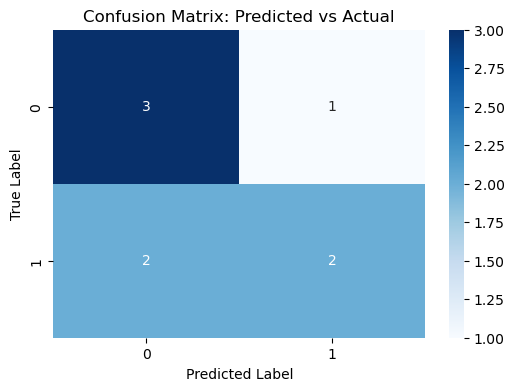

In [96]:
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Predicted vs Actual')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

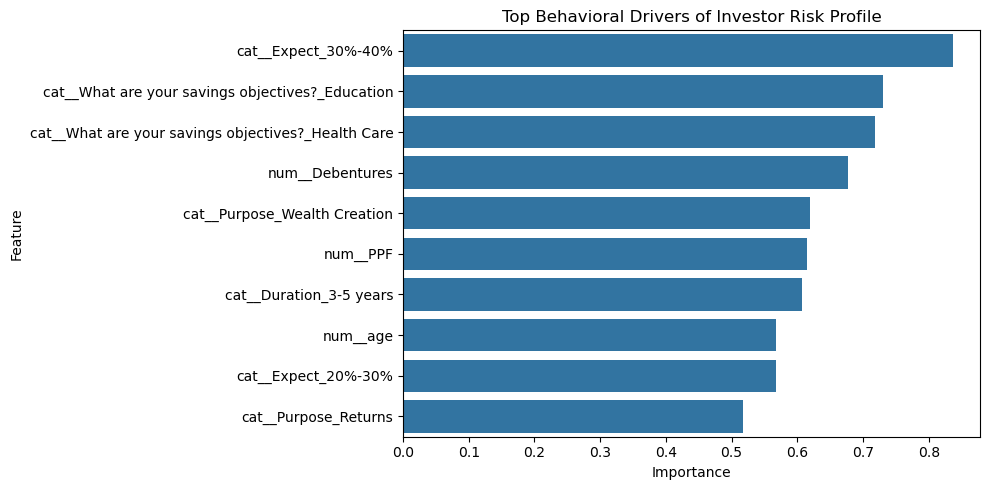

In [97]:
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = np.abs(pipeline.named_steps['model'].coef_[0])
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(10))
plt.title('Top Behavioral Drivers of Investor Risk Profile')
plt.tight_layout()
plt.show()

The model indicates that investor risk classification is primarily driven by behavioral financial indicators rather than demographic attributes. In particular, expected returns (20%–40%), investment purpose (wealth creation and returns), and asset allocation preferences (PPF and debentures) are the strongest predictors of risk profile. Time horizon also plays a moderate role, while demographic factors such as age contribute less significantly.

In [100]:
joblib.dump(pipeline, 'models/investor_model.pkl')
joblib.dump(le, 'models/label_encoder.pkl')

['models/label_encoder.pkl']